# Felix

In [14]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
import seaborn as sns

# 1. Cargar el dataset desde la carpeta 'data'
df = pd.read_csv('data\\fake_job_postings.csv')


print(f"📊 Tamaño original del dataset: {df.shape}")


📊 Tamaño original del dataset: (17880, 18)


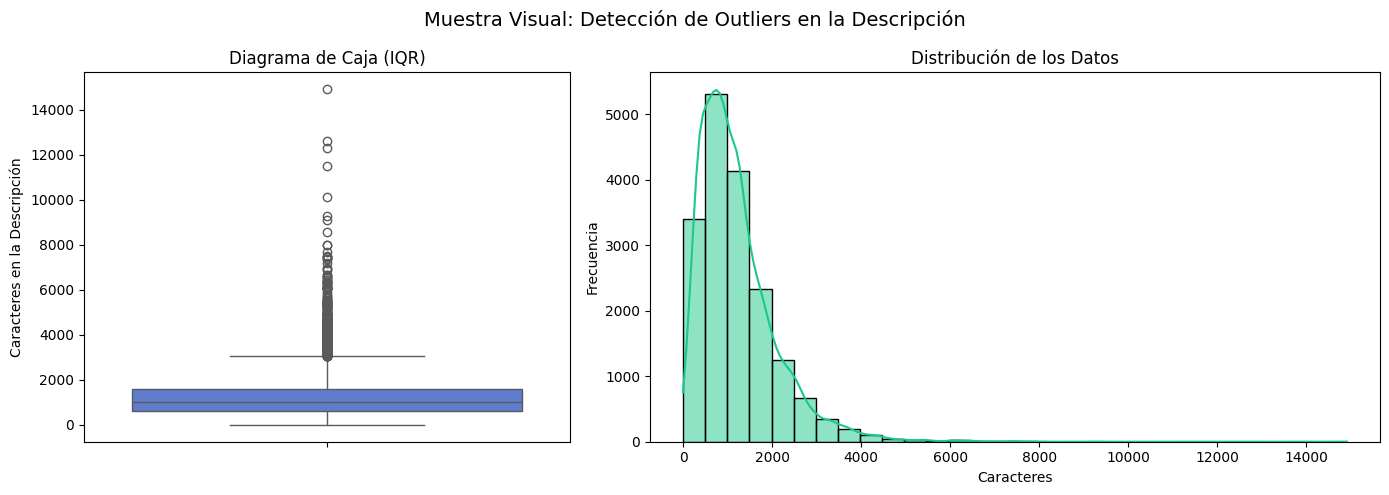

📊 Estadísticas de control:
count    17880.000000
mean      1218.004418
std        894.828620
min          0.000000
25%        607.000000
50%       1017.000000
75%       1586.000000
max      14907.000000
Name: longitud_descripcion, dtype: float64


In [17]:
# Crear la métrica de longitud de texto
df["longitud_descripcion"] = df["description"].fillna("").str.len()

# Configurar gráficos
fig, (ax_box, ax_hist) = plt.subplots(
    1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": (0.4, 0.6)}
)
fig.suptitle(
    "Muestra Visual: Detección de Outliers en la Descripción", fontsize=14
)

# 1. Boxplot (Muestra los puntos atípicos fuera de los bigotes)
sns.boxplot(ax=ax_box, y=df["longitud_descripcion"], color="#4e73df")
ax_box.set_title("Diagrama de Caja (IQR)")
ax_box.set_ylabel("Caracteres en la Descripción")

# 2. Histograma (Muestra la distribución real)
sns.histplot(
    ax=ax_hist, x=df["longitud_descripcion"], bins=30, kde=True, color="#1cc88a")
ax_hist.set_title("Distribución de los Datos")
ax_hist.set_xlabel("Caracteres")
ax_hist.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Resumen numérico en consola
print("📊 Estadísticas de control:")
print(df["longitud_descripcion"].describe())

In [20]:
total_original = df.shape[0]

# 2. Calcular la métrica temporal
df["_len_desc"] = df["description"].fillna("").str.len()

# 3. Aplicar el filtro del Rango Intercuartílico (IQR)
Q1 = df["_len_desc"].quantile(0.25)
Q3 = df["_len_desc"].quantile(0.75)
IQR = Q3 - Q1

# Definir límites (El estándar es 1.5 veces el IQR)
limite_inferior = max(
    10, Q1 - 1.5 * IQR
)  # Evitamos longitudes negativas, exigimos al menos 10 caracteres
limite_superior = Q3 + 1.5 * IQR

# 4. Filtrar el DataFrame
df_limpio = df[(df["_len_desc"] >= limite_inferior) & (df["_len_desc"] <= limite_superior)].copy()

# Eliminar la columna auxiliar
df_limpio.drop(columns=["_len_desc"], inplace=True)

# 5. Guardar resultados
outliers_eliminados = total_original - df_limpio.shape[0]
print(f"🧹 ¡Limpieza completada!")
print(f"🔹 Filas originales: {total_original}")
print(f"🔹 Outliers eliminados: {outliers_eliminados}")
print(f"🔹 Filas actuales: {df_limpio.shape[0]}")

output_path = os.path.join("data", "fake_job_postings_clean.csv")
df_limpio.to_csv(output_path, index=False)
print(f"💾 Guardado en: {output_path}")

🧹 ¡Limpieza completada!
🔹 Filas originales: 17880
🔹 Outliers eliminados: 728
🔹 Filas actuales: 17152
💾 Guardado en: data\fake_job_postings_clean.csv
